In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## chargeaons notre dataset

In [2]:
df = pd.read_csv("paysim dataset.csv")

In [3]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df= df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

In [6]:
df.value_counts('type')

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [7]:
df.value_counts('isFraud')

isFraud
0    6354407
1       8213
Name: count, dtype: int64

## le dataset nous montre tres peu de fraude et un target tres desequilibré

In [8]:
df.isnull().sum()

step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [9]:
df.groupby('type')['isFraud'].sum()

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

## les fraudeur utilisennt regulierement les retraits d'argent et les transfervers un autre compte

In [10]:
df.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


## les faudes ont des montant bien plus elevé que les transaction normale

In [11]:
df.groupby('isFraud')[['oldbalanceOrg', 'newbalanceOrig']].describe()

oldbalanceOrg                                                         \
                count          mean           std  min        25%        50%   
isFraud                                                                        
0           6354407.0  8.328287e+05  2.887144e+06  0.0       0.00   14069.00   
1              8213.0  1.649668e+06  3.547719e+06  0.0  125822.44  438983.45   

                                 newbalanceOrig                               \
                75%          max          count           mean           std   
isFraud                                                                        
0         106969.50  43818855.30      6354407.0  855970.228109  2.924987e+06   
1        1517771.48  59585040.37         8213.0  192392.631836  1.965666e+06   

                                                
         min  25%  50%        75%          max  
isFraud                                         
0        0.0  0.0  0.0  144730.74  43686616.33  
1        0.0  0.0  0.0       0.00  49585040.37

## le fraudeur a pour habitude de tous vider en une seule fois le compte d'origine

In [12]:
df.groupby('isFraud')[['oldbalanceDest', 'newbalanceDest']].describe()

oldbalanceDest                                                  \
                 count          mean           std  min  25%       50%   
isFraud                                                                  
0            6354407.0  1.101421e+06  3.399202e+06  0.0  0.0  133311.8   
1               8213.0  5.442496e+05  3.336421e+06  0.0  0.0       0.0   

                                 newbalanceDest                              \
               75%           max          count          mean           std   
isFraud                                                                       
0        944144.58  3.560159e+08      6354407.0  1.224926e+06  3.673816e+06   
1        147828.66  2.362305e+08         8213.0  1.279708e+06  3.908817e+06   

                                                         
         min  25%        50%          75%           max  
isFraud                                                  
0        0.0  0.0  214881.70  1111975.345  3.561793e+08  
1        0.0  0.0    4676.42  1058725.220  2.367265e+08

## et donc par consequent recoit aussi plus dans son nouveau compte

## par contre il faudra prevoir au cas ou le voleur decide de vider le compte et transferer dans different compte

In [13]:
df['errorBalanceOrig']= df['oldbalanceOrg']- df['amount']- df['newbalanceOrig']

In [14]:
df['errorBalanceOrig'].describe()

count    6.362620e+06
mean    -2.010925e+05
std      6.066505e+05
min     -9.244552e+07
25%     -2.496411e+05
50%     -6.867726e+04
75%     -2.954230e+03
max      1.000000e-02
Name: errorBalanceOrig, dtype: float64

In [15]:
df.groupby('isFraud')['errorBalanceOrig'].mean()

isFraud
0   -201338.558109
1    -10692.325265
Name: errorBalanceOrig, dtype: float64

## nous devons retenir de cette soustraction quil ya des frais bancaire qui ne sont pas enregistrer mais au moins les fraudeur ont des transaction plus logique en surface

In [16]:
df['errorBalanceDest']= df['newbalanceDest']- df['oldbalanceDest']- df['amount']

In [17]:
df.groupby('isFraud')['errorBalanceDest'].mean()

isFraud
0    -54692.231734
1   -732509.301069
Name: errorBalanceDest, dtype: float64

In [18]:
df = pd.get_dummies(df, columns=['type'], dtype=int)
print(df.columns.tolist())
print(df.shape)

['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'errorBalanceOrig', 'errorBalanceDest', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
(6362620, 14)


In [19]:
df

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.00,160296.36,0.00,0.00,0,0.0,-9.839640e+03,0,0,0,1,0
1,1,1864.28,21249.00,19384.72,0.00,0.00,0,0.0,-1.864280e+03,0,0,0,1,0
2,1,181.00,181.00,0.00,0.00,0.00,1,0.0,-1.810000e+02,0,0,0,0,1
3,1,181.00,181.00,0.00,21182.00,0.00,1,0.0,-2.136300e+04,0,1,0,0,0
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,0.0,-1.166814e+04,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,1,0.0,0.000000e+00,0,1,0,0,0
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,1,0.0,-6.311409e+06,0,0,0,0,1
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0.0,-1.000000e-02,0,1,0,0,0
6362618,743,850002.52,850002.52,0.00,0.00,0.00,1,0.0,-8.500025e+05,0,0,0,0,1


## il ne mat utile de garder uniquement les types CASH OUT ET TRANSFER qui sont utilisé par les voleurs

In [20]:
df.drop(columns=['type_CASH_IN', 'type_DEBIT', 'type_PAYMENT'], inplace=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column            Dtype  
---  ------            -----  
 0   step              int64  
 1   amount            float64
 2   oldbalanceOrg     float64
 3   newbalanceOrig    float64
 4   oldbalanceDest    float64
 5   newbalanceDest    float64
 6   isFraud           int64  
 7   errorBalanceOrig  float64
 8   errorBalanceDest  float64
 9   type_CASH_OUT     int64  
 10  type_TRANSFER     int64  
dtypes: float64(7), int64(4)
memory usage: 534.0 MB


In [24]:
df.shape

(6362620, 11)

In [25]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest,type_CASH_OUT,type_TRANSFER
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,-2.010925e+05,-5.556717e+04,3.516633e-01,8.375622e-02
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,6.066505e+05,4.415288e+05,4.774895e-01,2.770219e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.244552e+07,-1.319123e+07,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.496411e+05,-2.935305e+04,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,-6.867726e+04,-3.500490e+03,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,-2.954230e+03,0.000000e+00,1.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e-02,7.588573e+07,1.000000e+00,1.000000e+00


## commencons notre modele xgboost

In [26]:
x = df.drop(columns=['isFraud'])
y = df['isFraud']

In [27]:
print(x.shape)
print(y.shape)

(6362620, 10)
(6362620,)


In [28]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print(x_train.shape)
print(x_test.shape)
print(y_train.value_counts())

(5090096, 10)
(1272524, 10)
isFraud
0    5083526
1       6570
Name: count, dtype: int64


In [31]:
scale_pos_weight = y_train.value_counts()[0]/ y_train.value_counts()[1]

In [32]:
print(f"la ponderation des classe: {scale_pos_weight:.2F}")

la ponderation des classe: 773.75


In [33]:
from xgboost import XGBClassifier

model = XGBClassifier(
    scale_pos_weight=773.75,
    random_state=42,
    n_jobs=-1

)

model.fit(x_train, y_train)
print("entrainement terminée")

entrainement terminée


In [34]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.97      1.00      0.98      1643

    accuracy                           1.00   1272524
   macro avg       0.99      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524



In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1270833      48]
 [      8    1635]]


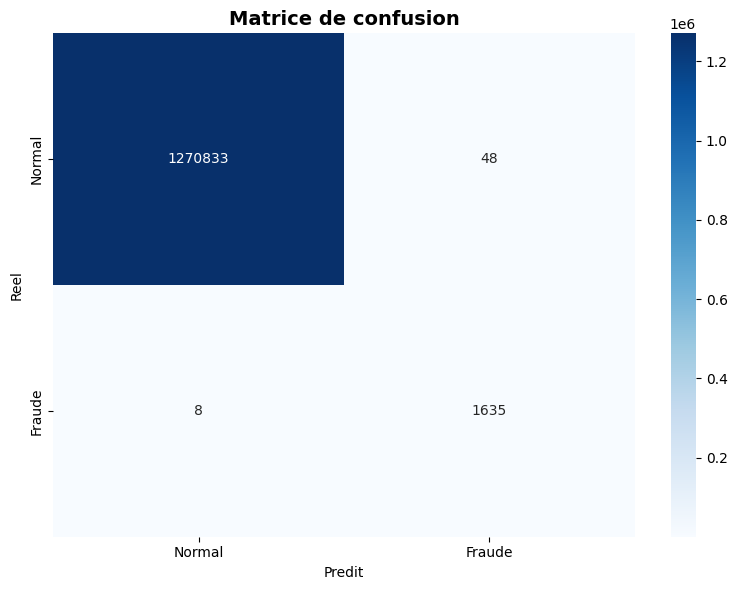

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.title('Matrice de confusion', fontsize=14, fontweight='bold')
plt.ylabel('Reel')
plt.xlabel('Predit')
plt.tight_layout()
plt.show()

## il arrive quand meme a predire les cas de fraude 

In [43]:
y_pred_proba= model.predict_proba(x_test)[:, 1]



In [48]:
fraude_scores = y_pred_proba[y_test == 1]

print(f"Min  : {fraude_scores.min():.4f}")
print(f"Max  : {fraude_scores.max():.4f}")
print(f"Moyenne  : {fraude_scores.mean():.4f}")

Min  : 0.0000
Max  : 1.0000
Moyenne  : 0.9950


In [49]:
normal_scores = y_pred_proba[y_test== 0]
print(f"Min  : {normal_scores.min():.4f}")
print(f"Max  : {normal_scores.max():.4f}")
print(f"Moyenne  : {normal_scores.mean():.4f}")

Min  : 0.0000
Max  : 1.0000
Moyenne  : 0.0001


In [50]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC : {auc:.4f}")

AUC-ROC : 0.9997


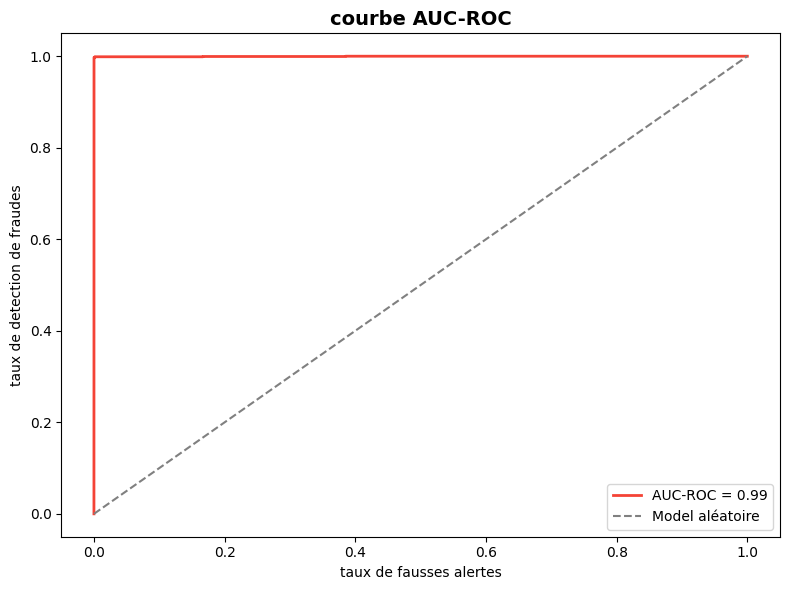

In [55]:
from sklearn.metrics import roc_curve

fpr, tpr, threosholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize= (8, 6))
plt.plot(fpr, tpr, color='#F44336', lw=2,
         label=f'AUC-ROC = 0.99')
plt.plot([0, 1], [0, 1], color='gray',
         linestyle='--', label='Model aléatoire')
plt.xlabel('taux de fausses alertes')
plt.ylabel('taux de detection de fraudes')
plt.title('courbe AUC-ROC', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

         

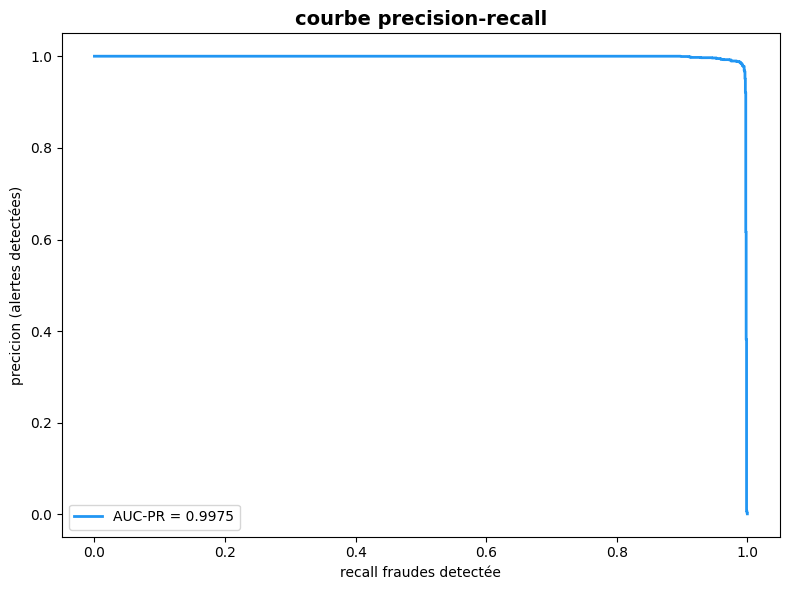

In [56]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall , thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#2196F3', lw=2,
         label=f'AUC-PR = {pr_auc:.4f}')


plt.xlabel('recall fraudes detectée')
plt.ylabel('precicion (alertes detectées)')
plt.title('courbe precision-recall', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
import joblib

joblib.dump(model, 'modele_fraude.pkl')

print("modèle sauvegarder")

modèle sauvegarder


# PARTIE II AVEC LES CHAINE DE TRANSASACTION

In [2]:
import pandas as pd

classes  = pd.read_csv('fraude partie 2/elliptic_bitcoin_dataset/elliptic_txs_classes.csv')
edges    = pd.read_csv('fraude partie 2/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv')
features = pd.read_csv('fraude partie 2/elliptic_bitcoin_dataset/elliptic_txs_features.csv', header=None)

classes.shape, edges.shape, features.shape

((203769, 2), (234355, 2), (203769, 167))

In [4]:
classes['class'].value_counts()

class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

In [5]:
edges.head()

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [6]:
features.iloc[:, :5]

,0,1,2,3,4
0,230425980,1,-0.171469,-0.184668,-1.201369
1,5530458,1,-0.171484,-0.184668,-1.201369
2,232022460,1,-0.172107,-0.184668,-1.201369
3,232438397,1,0.163054,1.963790,-0.646376
4,230460314,1,1.011523,-0.081127,-1.201369
...,...,...,...,...,...
203764,173077460,49,-0.145771,-0.163752,0.463609
203765,158577750,49,-0.165920,-0.123607,1.018602
203766,158375402,49,-0.172014,-0.078182,1.018602
203767,158654197,49,-0.172842,-0.176622,1.018602


In [7]:
features.columns = ['txId'] + [f'f{i}' for i in range(1, 167)]
df = features.merge(classes, on='txId')
df.shape

(203769, 168)

In [8]:
df['class'].value_counts()

class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64